# Likely ideal network to practice towards:
MPNNs (But Continuous-time, to respect time dynamics. So, MPNN + LSMT)

# Toy practice Tasks
1.  Node-level task: Social influence prediction
2.  Edge-level task: Traffic flow prediction 
3. Graph-level task: Molecular property prediction (QM9 dataset)

### Stage 0 — Graph primitives ≈ modeling a tiny circuit
1. Start with 3–5 neurons and some synapses, connected arbitrarily.  
	- Play with visualizing simple graphs (triangle, chain, ring).
2. Implement message passing by hand conceptually (messages aggregated from neighbors).
	- (matrix multiply + nonlinear activation).
3. Watch how information flows like postsynaptic potentials.

= You’ll intuit how messages traverse edges, and what “aggregation” means biophysically.  

Outcome: understand that a GNN layer ≈ one integration step of synaptic input.  

In [36]:
# Understanding Message Passing: Activity × Weight → Threshold Comparison

# Let's break down what's REALLY happening in message passing:
# 1. Neuron A has activity level (e.g., 0.8)
# 2. Synapse A→B has weight (e.g., 0.6) - this is synaptic strength
# 3. Message sent = 0.8 × 0.6 = 0.48
# 4. Neuron B accumulates ALL incoming messages
# 5. If total > threshold, neuron B "fires" (activates)

class DetailedNeuron:
    def __init__(self, num_neurons, connections):
        self.num_neurons = num_neurons
        self.connections = connections
        
        # Each neuron has an activation threshold (like firing threshold)
        self.thresholds = np.random.rand(num_neurons) * 0.3 + 0.2  # Between 0.2-0.5
        
        # Current activation levels
        self.activations = np.random.rand(num_neurons) * 0.5  # Start lower
        
        # Synaptic weights (connection strength)
        self.weights = {}
        for start, end in connections:
            self.weights[(start, end)] = np.random.rand() * 0.8 + 0.2  # 0.2-1.0
        
        # Track incoming messages for visualization
        self.incoming_messages = {i: [] for i in range(num_neurons)}
        
    def message_pass_step(self, show_details=False):
        """One step with detailed tracking"""
        # Clear previous messages
        self.incoming_messages = {i: [] for i in range(self.num_neurons)}
        
        # Collect all incoming messages
        total_input = np.zeros(self.num_neurons)
        
        for start, end in self.connections:
            # Calculate message: sender_activity × synaptic_weight
            message = self.activations[start] * self.weights[(start, end)]
            total_input[end] += message
            
            # Track for visualization
            self.incoming_messages[end].append({
                'from': start,
                'weight': self.weights[(start, end)],
                'sender_activity': self.activations[start],
                'message_value': message
            })
            
            if show_details:
                print(f"Neuron {start} (activity={self.activations[start]:.3f}) "
                      f"→ Neuron {end} via weight={self.weights[(start, end)]:.3f} "
                      f"= message {message:.3f}")
        
        # Apply threshold comparison and update activations
        new_activations = np.zeros(self.num_neurons)
        for i in range(self.num_neurons):
            if total_input[i] > self.thresholds[i]:
                # Neuron fires! Use sigmoid to get reasonable activation
                new_activations[i] = 1 / (1 + np.exp(-total_input[i]))
            else:
                # Below threshold - minimal activity
                new_activations[i] = total_input[i] * 0.1
                
            if show_details and len(self.incoming_messages[i]) > 0:
                print(f"Neuron {i}: total_input={total_input[i]:.3f}, "
                      f"threshold={self.thresholds[i]:.3f}, "
                      f"fires={'YES' if total_input[i] > self.thresholds[i] else 'NO'}")
        
        self.activations = new_activations
        return self.activations.copy()

# Test with detailed output
print("=== DETAILED MESSAGE PASSING EXAMPLE ===")
neurons, connections = create_triangle()
detailed_network = DetailedNeuron(neurons, connections)

print(f"Initial activations: {detailed_network.activations.round(3)}")
print(f"Thresholds: {detailed_network.thresholds.round(3)}")
print(f"Weights: {[(k, round(v, 3)) for k, v in detailed_network.weights.items()]}")
print()

print("--- Step 1 ---")
detailed_network.message_pass_step(show_details=True)
print(f"New activations: {detailed_network.activations.round(3)}")
print()


=== DETAILED MESSAGE PASSING EXAMPLE ===
Initial activations: [0.083 0.242 0.42 ]
Thresholds: [0.403 0.365 0.375]
Weights: [((0, 1), 0.805), ((1, 2), 0.325), ((2, 0), 0.981)]

--- Step 1 ---
Neuron 0 (activity=0.083) → Neuron 1 via weight=0.805 = message 0.067
Neuron 1 (activity=0.242) → Neuron 2 via weight=0.325 = message 0.079
Neuron 2 (activity=0.420) → Neuron 0 via weight=0.981 = message 0.412
Neuron 0: total_input=0.412, threshold=0.403, fires=YES
Neuron 1: total_input=0.067, threshold=0.365, fires=NO
Neuron 2: total_input=0.079, threshold=0.375, fires=NO
New activations: [0.602 0.007 0.008]



In [37]:
#1 Simple graph
neurons = 5
connections: [[4,1],[0,2],[1,3],[2,4],[3,0]]
[[1,2,3,4],[1,3],[1,4],[1,5],[2,3],[2,4],[2,5],[3,4],[3,5],[4,5]]
synapses_per_connection = range(0, 11)

#How do we know if its a triangle, chain, ring? connection pattern i presume
#2 Message passing
1. nodes begin with a message
2. edges receive messages from connected nodes
3. edges aggregate messages
4. nodes receive aggregated messages from connected edges



SyntaxError: invalid syntax (3828975983.py, line 9)

In [ ]:
print (synapses_per_connection)

-10


In [ ]:
# Let's start super simple - 4 neurons in different patterns
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create simple graphs (neuron connections)
def create_triangle():
    """3 neurons all connected to each other"""
    neurons = 3
    # Each neuron connects to the others
    connections = [(0,1), (1,2), (2,0)]
    return neurons, connections

def create_chain():
    """4 neurons in a line: 0->1->2->3"""
    neurons = 4  
    connections = [(0,1), (1,2), (2,3)]
    return neurons, connections

def create_ring():
    """4 neurons in a circle: 0->1->2->3->0"""
    neurons = 4
    connections = [(0,1), (1,2), (2,3), (3,0)]
    return neurons, connections

# Let's start with a triangle - simplest case
neurons, connections = create_triangle()
print(f"Triangle: {neurons} neurons, connections: {connections}")

neurons, connections = create_chain() 
print(f"Chain: {neurons} neurons, connections: {connections}")

neurons, connections = create_ring()
print(f"Ring: {neurons} neurons, connections: {connections}")


Triangle: 3 neurons, connections: [(0, 1), (1, 2), (2, 0)]
Chain: 4 neurons, connections: [(0, 1), (1, 2), (2, 3)]
Ring: 4 neurons, connections: [(0, 1), (1, 2), (2, 3), (3, 0)]


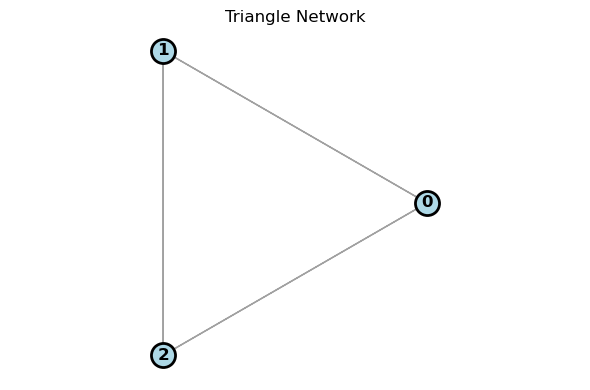

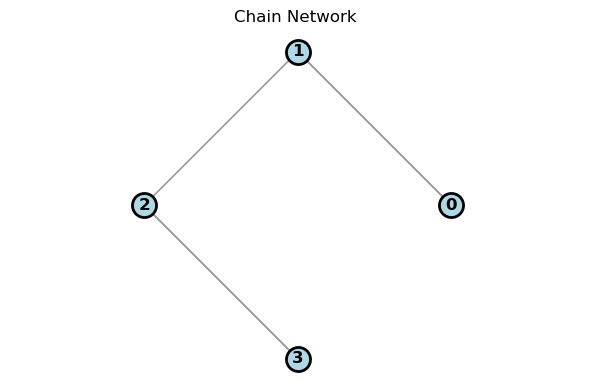

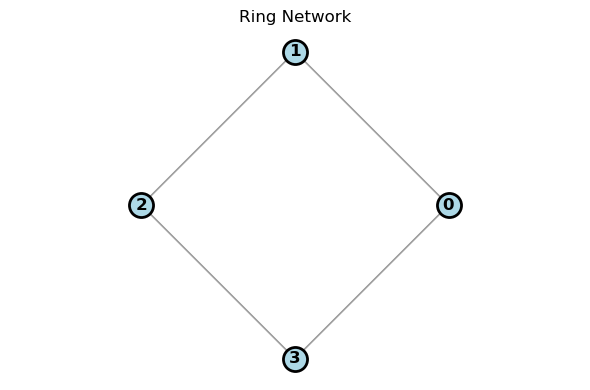

In [ ]:
# Step 1b: Visualize the graphs so we can see the neuron connections
def visualize_graph(neurons, connections, title="Neural Network"):
    """Super simple visualization of our neuron network"""
    plt.figure(figsize=(6, 4))
    
    # Position neurons in a circle for easy viewing
    angles = np.linspace(0, 2*np.pi, neurons, endpoint=False)
    x = np.cos(angles)
    y = np.sin(angles)
    
    # Draw connections (synapses)
    for start, end in connections:
        plt.arrow(x[start], y[start], 
                 x[end]-x[start], y[end]-y[start],
                 head_width=0.05, head_length=0.05, 
                 fc='gray', ec='gray', alpha=0.7)
    
    # Draw neurons
    plt.scatter(x, y, s=300, c='lightblue', edgecolors='black', linewidth=2)
    
    # Label neurons
    for i in range(neurons):
        plt.text(x[i], y[i], str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    
    plt.title(title)
    plt.axis('equal')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize all three patterns
neurons, connections = create_triangle()
visualize_graph(neurons, connections, "Triangle Network")

neurons, connections = create_chain()
visualize_graph(neurons, connections, "Chain Network") 

neurons, connections = create_ring()
visualize_graph(neurons, connections, "Ring Network")


In [ ]:
# Step 2: Message Passing - How neurons talk to each other!
class SimpleNeuron:
    def __init__(self, num_neurons, connections):
        self.num_neurons = num_neurons
        self.connections = connections
        
        # Each neuron starts with some "activation" (like electrical potential)
        self.activations = np.random.rand(num_neurons)  # Random starting values
        
        # Simple synaptic weights (how strong each connection is)
        self.weights = {}
        for start, end in connections:
            self.weights[(start, end)] = np.random.rand() * 0.5 + 0.5  # Between 0.5 and 1.0
    
    def message_pass_step(self):
        """One step of message passing - like one moment in time"""
        new_activations = np.zeros(self.num_neurons)
        
        # Each neuron receives messages from its neighbors
        for start, end in self.connections:
            # Neuron 'start' sends a message to neuron 'end'
            message = self.activations[start] * self.weights[(start, end)]
            new_activations[end] += message
        
        # Apply a simple activation function (like a neuron firing threshold)
        # Using tanh to keep values reasonable
        self.activations = np.tanh(new_activations + 0.1)  # +0.1 for some baseline activity
        
        return self.activations.copy()

# Let's test this on a triangle network
neurons, connections = create_triangle()
network = SimpleNeuron(neurons, connections)

print("Starting activations:", network.activations.round(3))
print("Connections:", connections)
print("Weights:", {k: round(v, 3) for k, v in network.weights.items()})

# Run a few steps and see how the signals propagate
print("\n--- Message Passing Steps ---")
for step in range(5):
    activations = network.message_pass_step()
    print(f"Step {step+1}: {activations.round(3)}")


Starting activations: [0.173 0.349 0.674]
Connections: [(0, 1), (1, 2), (2, 0)]
Weights: {(0, 1): 0.963, (1, 2): 0.824, (2, 0): 0.506}

--- Message Passing Steps ---
Step 1: [0.414 0.26  0.369]
Step 2: [0.279 0.461 0.305]
Step 3: [0.249 0.353 0.446]
Step 4: [0.315 0.327 0.372]
Step 5: [0.28  0.382 0.353]


# Step 2: Node classificaiton
Features = calcium amplitude statistics

Objective, determine which neurons are inhibitory vs excitory from the morphology?


In [ ]:
###Exercise 1: NODE CLASSIFICATION
Example: xyz
# Graph type: GraphSAGE
